In [50]:
import numpy as np
from matplotlib import pyplot as plt
# from pathlib import Path

In [51]:
with np.load("comparison_results/fem_comparison_snapshots.npz") as data:
    points = data["points"]
    times  = data["times"]
    u_fem  = data["u"]

In [52]:
with np.load("comparison_results/pinn_comparison_snapshots.npz") as data:
    points = data["points"]
    times  = data["times"]
    u_pinn = data["u"]

In [53]:
if u_fem.shape != u_pinn.shape:
    raise ValueError(f"Shape mismatch: FEM {u_fem.shape}, PINN {u_pinn.shape}")

In [54]:
# Reconstruct the regular Cartesian grid from comparison points
x = np.unique(points[:, 0])
y = np.unique(points[:, 1])
x_grid, y_grid = np.meshgrid(x, y, indexing="xy")

# Locate each comparison point in the grid
x_indices = np.searchsorted(x, points[:, 0])
y_indices = np.searchsorted(y, points[:, 1])

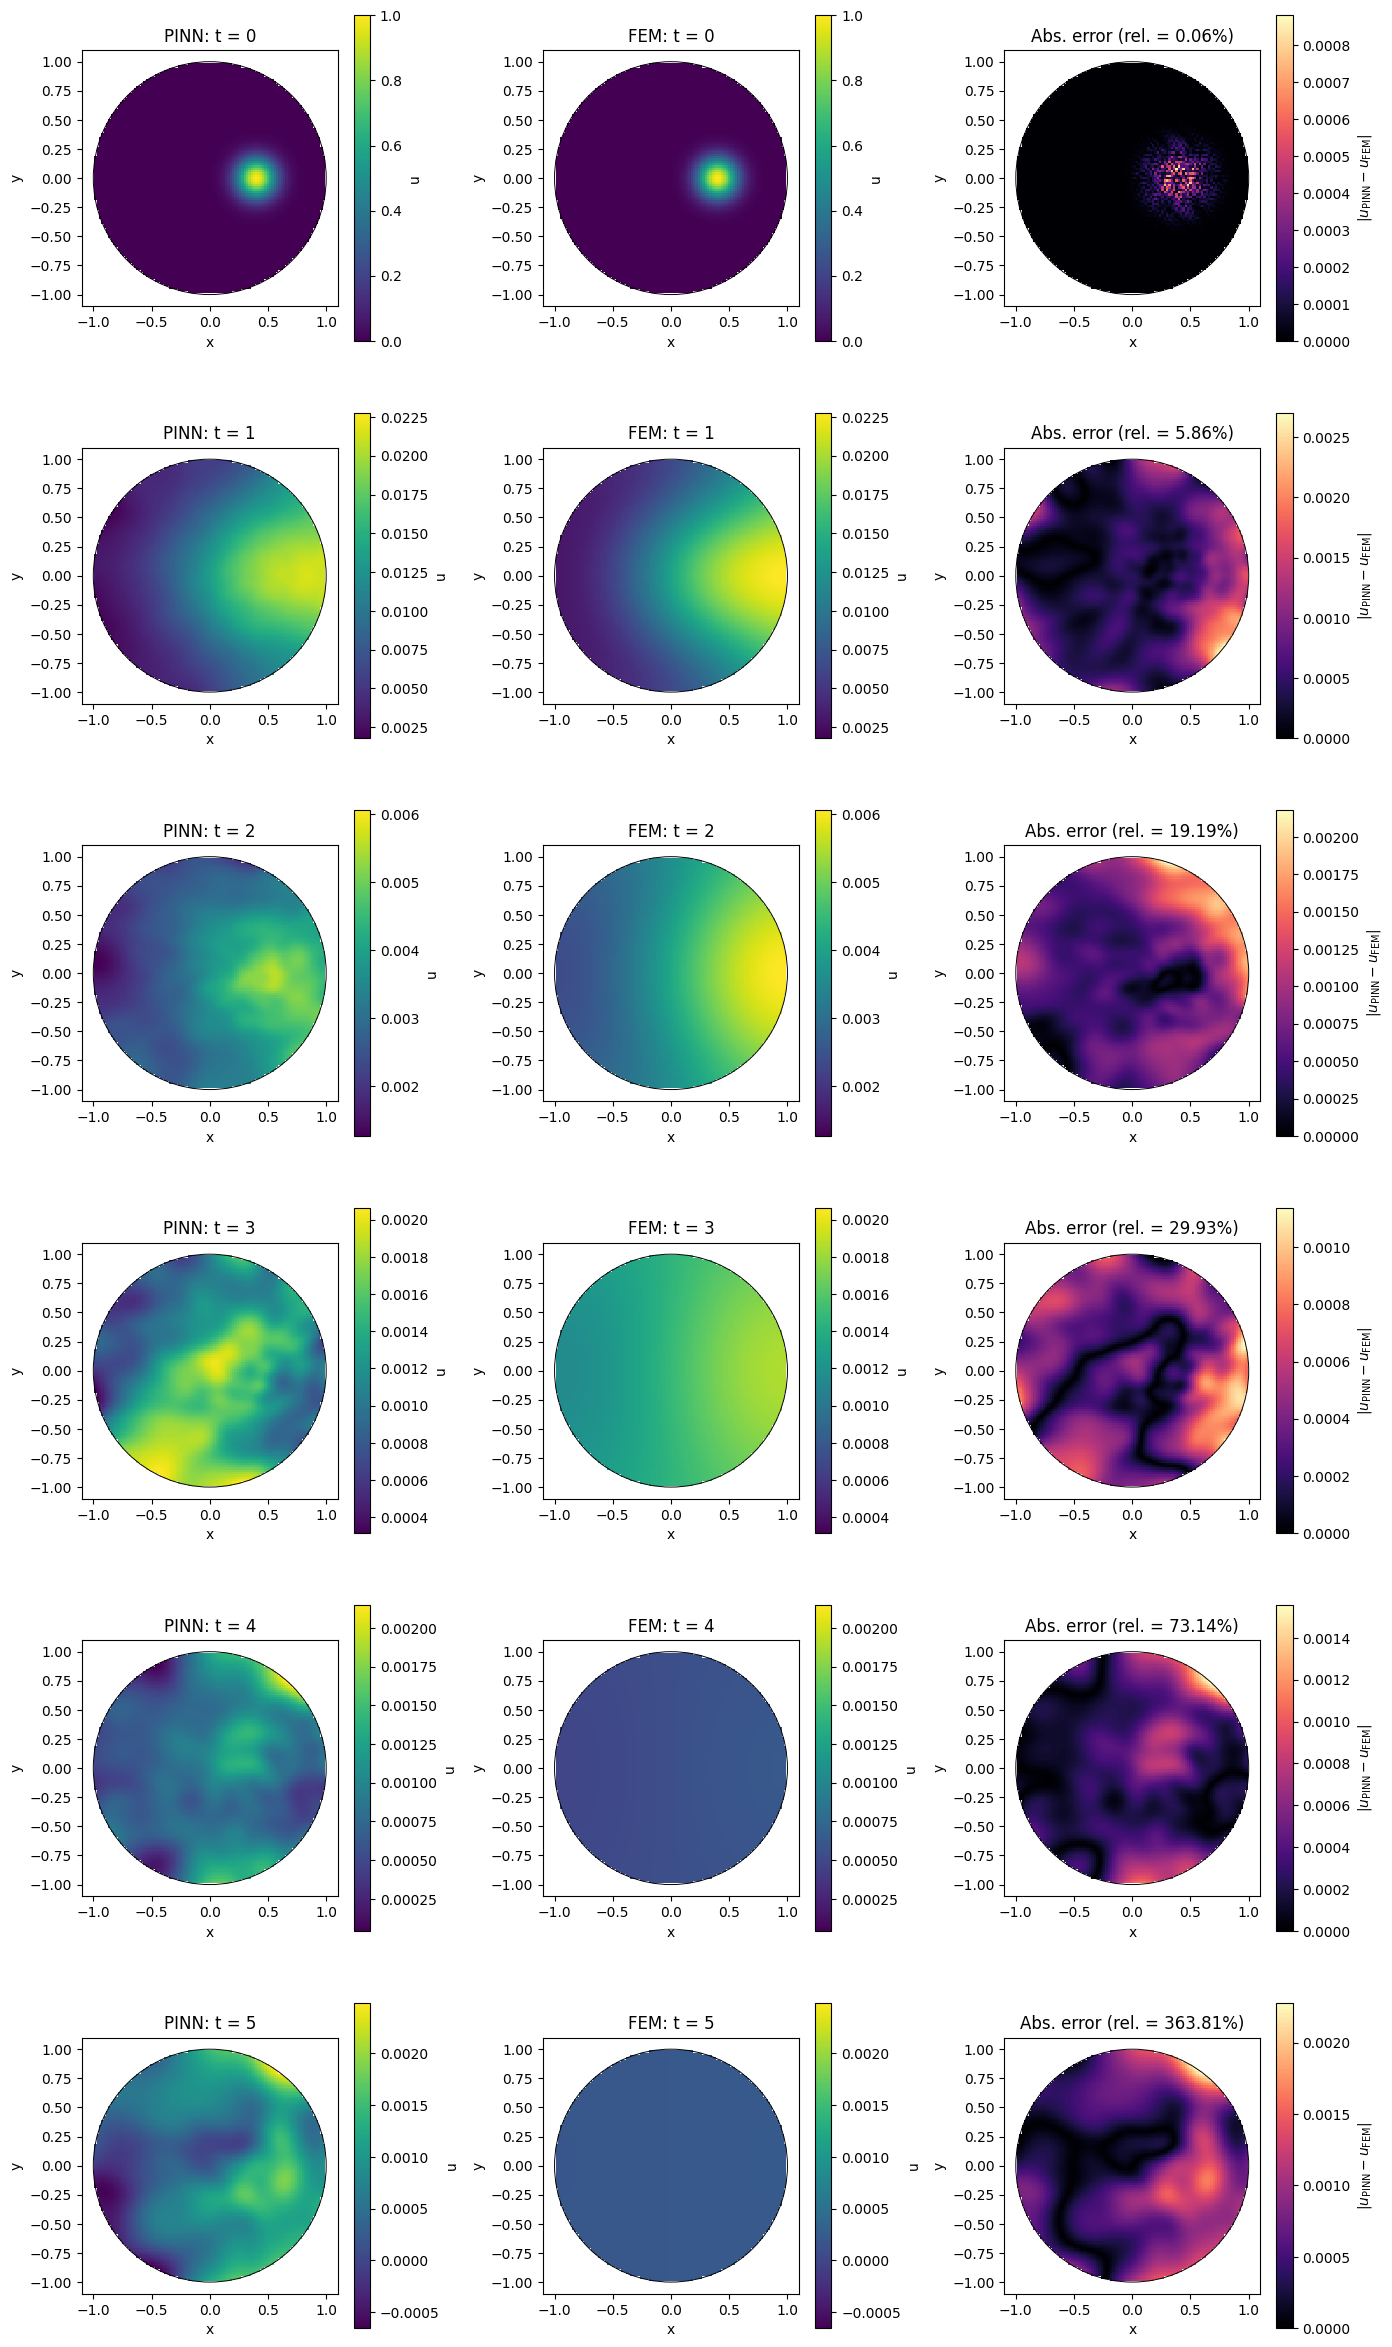

In [55]:
rows = len(times)
fig, axes = plt.subplots(
    rows, 3,
    figsize=(14, 4 * rows),
    squeeze=False,
)

for i, time in enumerate(times):
    pinn_field = np.full(x_grid.shape, np.nan)
    fem_field = np.full(x_grid.shape, np.nan)

    pinn_field[y_indices, x_indices] = u_pinn[i]
    fem_field[y_indices, x_indices] = u_fem[i]

    error_field = np.abs(pinn_field - fem_field)

    difference_norm = np.linalg.norm(u_pinn[i] - u_fem[i])
    fem_norm = np.linalg.norm(u_fem[i])
    if fem_norm > 0:
        relative_l2_percent = 100 * difference_norm / fem_norm
    else:
        relative_l2_percent = 0.0 if difference_norm == 0 else np.inf

    # Shared colour scale for PINN and FEM
    combined = np.concatenate((u_pinn[i], u_fem[i]))
    finite = np.isfinite(combined)
    value_min = combined[finite].min()
    value_max = combined[finite].max()

    if value_min == value_max:
        padding = max(abs(value_min), 1.0) * 1e-12
        value_min -= padding
        value_max += padding

    pinn_image = axes[i, 0].pcolormesh(
        x_grid, y_grid, pinn_field,
        shading="auto",
        cmap="viridis",
        vmin=value_min,
        vmax=value_max,
    )

    fem_image = axes[i, 1].pcolormesh(
        x_grid, y_grid, fem_field,
        shading="auto",
        cmap="viridis",
        vmin=value_min,
        vmax=value_max,
    )

    error_image = axes[i, 2].pcolormesh(
        x_grid, y_grid, error_field,
        shading="auto",
        cmap="magma",
        vmin=0,
    )

    axes[i, 0].set_title(f"PINN: t = {time:g}")
    axes[i, 1].set_title(f"FEM: t = {time:g}")
    axes[i, 2].set_title(
        f"Abs. error "
        f"(rel. = {relative_l2_percent:.2f}%)"
    )

    for axis in axes[i]:
        axis.add_patch(
            plt.Circle(
                (0, 0), 1,
                fill=False,
                color="black",
                linewidth=0.7,
            )
        )
        axis.set(
            aspect="equal",
            xlabel="x",
            ylabel="y",
        )

    fig.colorbar(pinn_image, ax=axes[i, 0], label="u")
    fig.colorbar(fem_image, ax=axes[i, 1], label="u")
    fig.colorbar(
        error_image,
        ax=axes[i, 2],
        label=r"$|u_{\mathrm{PINN}}-u_{\mathrm{FEM}}|$",
    )

fig.tight_layout()
plt.show()

# Optional:
# fig.savefig("comparison_results/comparison_snapshots.png",
#             dpi=180, bbox_inches="tight")

In [56]:
print('hi')

hi
